# FitzHugh–Nagumo benchmark of Ramsay et al. (2007): parametric forward problem with time-marching PINNs (PyTorch)

Model of Ramsay, Hooker, Campbell & Cao (2007), JRSS-B 69(5), Section 3.1:

$$
\frac{dV}{dt} = c\left(V - \frac{V^3}{3} + R\right), \qquad
\frac{dR}{dt} = -\frac{1}{c}\,\big(V - a + b\,R\big), \qquad
V(0) = -1,\; R(0) = 1,
$$

with $b = 0.2$, $c = 3$ fixed, on $t \in [0, 20]$.

**Parametric** version of `ramsay_fhn_forward_PINNs-torch.ipynb`: the networks take $(t, a)$ as input
and are trained once for all $a \in [0.1, 0.5]$. After training, the solution for any $a$ in that
range is a single forward pass. This is still the forward problem: no data and no parameter estimation.
The networks are trained only on the ODE residual, and RK45 is used purely for validation.

Over $a \in [0.1, 0.5]$ the second upstroke of $V$ moves from $t \approx 9.5$ to $10.3$ and the
downstrokes by up to $2.5$ time units (at $a = 0.5$ the third upstroke falls outside $[0, 20]$), so the
networks must represent sharp fronts whose position depends on $a$.

Framework, network and training loop are the same as in the fixed-$a$ notebook: $[0, 20]$ is split
into windows of length 2, each window has its own small MLP, and its initial condition is the end
state of the previous window, now as a function of $a$.

## Parameters (edit here)

In [1]:
# ---------------- ODE parameters (Ramsay et al. 2007, Sec. 3.1) ----------------
a_min, a_max = 0.1, 0.5   # range of the parameter a (network input)
b = 0.2
c = 3.0

# ---------------- Initial conditions ----------------
V0 = -1.0
R0 = 1.0

# ---------------- Time interval ----------------
t0      = 0.0
t_final = 20.0
n_eval  = 4000     # output grid in t for comparison

# ---------------- Time-marching PINN settings ----------------
window_length  = 2.0    # length of each time window
n_colloc       = 400    # collocation points in t per window (uniform grid)
n_a_train      = 21     # training values of a (uniform grid on [a_min, a_max])
hidden_layers  = 3
hidden_width   = 32
adam_epochs    = 500    # Adam warm-up per window
adam_lr        = 1.0e-3
lbfgs_max_iter = 3000   # L-BFGS refinement per window
seed           = 0
num_threads    = 16     # CPU threads for torch

# ---------------- Validation ----------------
n_a_test = 81           # values of a for the error-vs-a curve (includes values between training a)

## Imports and setup

In [ ]:
import time
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"   # or "1" to use the second GPU

import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy.integrate import solve_ivp
from torch import nn

torch.manual_seed(seed)
np.random.seed(seed)
torch.set_num_threads(num_threads)

# float32 on GPU if available, otherwise CPU + float64 (same logic as the torch FHN notebook).
# In float32, L-BFGS typically stalls at residual losses ~1e-6.
if torch.cuda.is_available():
    device = torch.device("cuda")
    dtype = torch.float32
else:
    device = torch.device("cpu")
    dtype = torch.float64
# device = torch.device("cpu")
# dtype = torch.float64
print(f"torch {torch.__version__}, device {device}, dtype {dtype}")

torch 2.1.0, device cpu, dtype torch.float64


## Model

Inside window $[t_k, t_{k+1}]$, with $s = (t - t_k)/(t_{k+1} - t_k) \in [0, 1]$ and
$\hat a = 2(a - a_{\min})/(a_{\max} - a_{\min}) - 1 \in [-1, 1]$,

$$
\big(V, R\big)(t, a) = \big(V_k, R_k\big)(a) + s\,\mathcal{N}_{\theta_k}(2s - 1,\ \hat a),
$$

where $(V_k, R_k)(a)$ is the end state of window $k-1$ at the same $a$ (for $k = 0$, the initial
condition $(V_0, R_0)$). The initial condition and continuity between windows hold exactly for every $a$.

The loss is the mean squared ODE residual over the tensor grid of $t$ collocation points and training
values of $a$, with the same scaling as the fixed-$a$ notebook (both residuals $O(1)$):

$$
\mathcal{L} = \frac{1}{N}\sum_i \Big(\tfrac{1}{c}\dot V - V + \tfrac{V^3}{3} - R\Big)^2
+ \Big(c\,\dot R + V - a_i + b R\Big)^2 .
$$

In [3]:
class WindowPINN(nn.Module):
    # MLP on one time window, input (t, a), with a hard-coded (a-dependent) initial condition.

    def __init__(self, t_a, t_b, hidden_layers, hidden_width):
        super().__init__()
        self.t_a, self.t_b = t_a, t_b
        layers, width_in = [], 2
        for _ in range(hidden_layers):
            linear = nn.Linear(width_in, hidden_width)
            nn.init.xavier_normal_(linear.weight)
            nn.init.zeros_(linear.bias)
            layers += [linear, nn.Tanh()]
            width_in = hidden_width
        output = nn.Linear(width_in, 2)
        nn.init.xavier_normal_(output.weight)
        nn.init.zeros_(output.bias)
        layers.append(output)
        self.net = nn.Sequential(*layers)

    def forward(self, t, a, y_start):
        # t, a: (N, 1); y_start: (N, 2) state at t_a for each point's value of a.
        s = (t - self.t_a) / (self.t_b - self.t_a)
        a_hat = 2.0 * (a - a_min) / (a_max - a_min) - 1.0
        return y_start + s * self.net(torch.cat([2.0 * s - 1.0, a_hat], dim=1))


def ode_residual(model, t, a, y_start):
    t = t.detach().requires_grad_(True)
    y = model(t, a, y_start)
    V, R = y[:, 0:1], y[:, 1:2]
    dV = torch.autograd.grad(V, t, torch.ones_like(V), create_graph=True)[0]
    dR = torch.autograd.grad(R, t, torch.ones_like(R), create_graph=True)[0]
    r_V = dV / c - (V - V**3 / 3.0 + R)
    r_R = c * dR + (V - a + b * R)
    return r_V, r_R


def residual_loss(model, t, a, y_start):
    r_V, r_R = ode_residual(model, t, a, y_start)
    return (r_V**2 + r_R**2).mean()


def window_start_states(models, a):
    # State (V, R) at the start of window len(models), for each a (tensor (N, 1)), by marching
    # through the already trained windows.
    y = torch.tensor([V0, R0], dtype=dtype, device=device).expand(a.shape[0], 2)
    with torch.no_grad():
        for model in models:
            t_end = torch.full_like(a, model.t_b)
            y = model(t_end, a, y)
    return y

## Train window by window (Adam warm-up, then L-BFGS)

Collocation points in window $k$ are the tensor grid of `n_colloc` values of $t$ and `n_a_train`
values of $a$. The start state of each point comes from the already trained windows at the same $a$
and is fixed (no gradient) while window $k$ is trained.

In [4]:
a_train = torch.linspace(a_min, a_max, n_a_train, dtype=dtype, device=device)


def train_window(t_a, t_b, models):
    model = WindowPINN(t_a, t_b, hidden_layers, hidden_width).to(device, dtype)
    t_grid = torch.linspace(t_a, t_b, n_colloc, dtype=dtype, device=device)
    T, A = torch.meshgrid(t_grid, a_train, indexing="ij")
    t_col, a_col = T.reshape(-1, 1), A.reshape(-1, 1)
    y_start = window_start_states(models, a_col)
    history = []

    adam = torch.optim.Adam(model.parameters(), lr=adam_lr)
    for _ in range(adam_epochs):
        adam.zero_grad()
        loss = residual_loss(model, t_col, a_col, y_start)
        loss.backward()
        adam.step()
        history.append(loss.item())

    lbfgs = torch.optim.LBFGS(
        model.parameters(),
        lr=1.0,
        max_iter=lbfgs_max_iter,
        history_size=100,
        tolerance_grad=1e-12,
        tolerance_change=1e-16,
        line_search_fn="strong_wolfe",
    )

    def closure():
        lbfgs.zero_grad()
        loss = residual_loss(model, t_col, a_col, y_start)
        loss.backward()
        history.append(loss.item())
        return loss

    lbfgs.step(closure)
    return model, history


edges = np.arange(t0, t_final + 1e-9, window_length)
if edges[-1] < t_final:
    edges = np.append(edges, t_final)

models, histories = [], []
start = time.time()
for t_a, t_b in zip(edges[:-1], edges[1:]):
    model, history = train_window(float(t_a), float(t_b), models)
    models.append(model)
    histories.append(history)
    print(f"window [{t_a:5.1f}, {t_b:5.1f}]  final loss {history[-1]:.2e}  "
          f"({len(history)} evals, {time.time() - start:.0f}s)")

window [  0.0,   2.0]  final loss 3.89e-07  (4250 evals, 40s)
window [  2.0,   4.0]  final loss 7.87e-08  (4174 evals, 80s)
window [  4.0,   6.0]  final loss 4.10e-07  (4251 evals, 120s)
window [  6.0,   8.0]  final loss 8.91e-07  (4045 evals, 159s)
window [  8.0,  10.0]  final loss 1.59e-06  (4199 evals, 199s)
window [ 10.0,  12.0]  final loss 1.18e-06  (3701 evals, 236s)
window [ 12.0,  14.0]  final loss 5.47e-07  (4251 evals, 276s)
window [ 14.0,  16.0]  final loss 8.24e-07  (3678 evals, 310s)
window [ 16.0,  18.0]  final loss 6.69e-07  (3703 evals, 345s)
window [ 18.0,  20.0]  final loss 1.75e-06  (4251 evals, 383s)


## Evaluate the PINN and the RK45 reference for many values of $a$

`pinn_predict(t, a_values)` returns $V$ and $R$ on the grid `a_values` × `t`. The error-vs-$a$
curve uses `n_a_test` values of $a$, most of which lie between the training values.

In [5]:
def pinn_predict(t, a_values):
    # Evaluate the piecewise parametric PINN; returns V, R with shape (len(a_values), len(t)).
    t = np.asarray(t, dtype=np.float64)
    a_values = np.asarray(a_values, dtype=np.float64)
    a_col = torch.tensor(a_values[:, None], dtype=dtype, device=device)
    idx = np.clip(np.searchsorted(edges, t, side="right") - 1, 0, len(models) - 1)
    out = np.empty((a_values.size, t.size, 2))
    y_start = torch.tensor([V0, R0], dtype=dtype, device=device).expand(a_values.size, 2)
    with torch.no_grad():
        for k, model in enumerate(models):
            mask = idx == k
            if mask.any():
                tk = torch.tensor(t[mask], dtype=dtype, device=device)
                T, A = torch.meshgrid(tk, a_col[:, 0], indexing="ij")          # (n_t_k, n_a)
                Y0 = y_start[None].expand(tk.numel(), -1, -1).reshape(-1, 2)
                y = model(T.reshape(-1, 1), A.reshape(-1, 1), Y0)
                out[:, mask] = y.reshape(tk.numel(), a_values.size, 2).transpose(0, 1).cpu().numpy()
            y_start = model(torch.full_like(a_col, model.t_b), a_col, y_start)
    return out[..., 0], out[..., 1]


def fitzhugh_nagumo_ramsay(t, y, a, b, c):
    V, R = y
    dV = c * (V - V**3 / 3.0 + R)
    dR = -(V - a + b * R) / c
    return [dV, dR]


t = np.linspace(t0, t_final, n_eval)
a_test = np.linspace(a_min, a_max, n_a_test)
V, R = pinn_predict(t, a_test)

# Tight tolerances so the reference error is negligible next to the PINN error.
V_ref, R_ref = np.empty_like(V), np.empty_like(R)
for i, a in enumerate(a_test):
    sol = solve_ivp(fitzhugh_nagumo_ramsay, (t0, t_final), [V0, R0], method="RK45", t_eval=t,
                    args=(a, b, c), rtol=1e-10, atol=1e-12)
    V_ref[i], R_ref[i] = sol.y

rel_l2 = np.sqrt(np.sum((V - V_ref)**2 + (R - R_ref)**2, axis=1)
                 / np.sum(V_ref**2 + R_ref**2, axis=1))
rel_l2_V = np.linalg.norm(V - V_ref, axis=1) / np.linalg.norm(V_ref, axis=1)
rel_l2_R = np.linalg.norm(R - R_ref, axis=1) / np.linalg.norm(R_ref, axis=1)
print(f"relative L2 error (V, R) over a in [{a_min}, {a_max}]: "
      f"mean {rel_l2.mean():.3e}, max {rel_l2.max():.3e} (at a = {a_test[rel_l2.argmax()]:.3f})")
print(f"max |V - V_ref| = {np.abs(V - V_ref).max():.3e},  max |R - R_ref| = {np.abs(R - R_ref).max():.3e}")

relative L2 error (V, R) over a in [0.1, 0.5]: mean 1.560e-03, max 5.341e-03 (at a = 0.500)
max |V - V_ref| = 3.662e-02,  max |R - R_ref| = 7.174e-03


## Relative error vs $a$

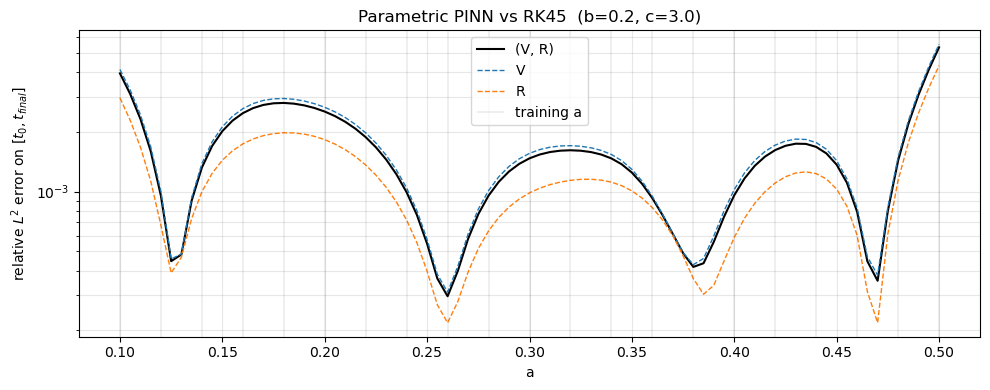

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.semilogy(a_test, rel_l2, "k-", lw=1.5, label="(V, R)")
ax.semilogy(a_test, rel_l2_V, "--", lw=1.0, label="V")
ax.semilogy(a_test, rel_l2_R, "--", lw=1.0, label="R")
for i, a in enumerate(a_train.cpu().numpy()):
    ax.axvline(a, color="k", lw=0.3, alpha=0.3, label="training a" if i == 0 else None)
ax.set_xlabel("a")
ax.set_ylabel(r"relative $L^2$ error on $[t_0, t_{final}]$")
ax.set_title(f"Parametric PINN vs RK45  (b={b}, c={c})")
ax.legend()
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

## Training history per window

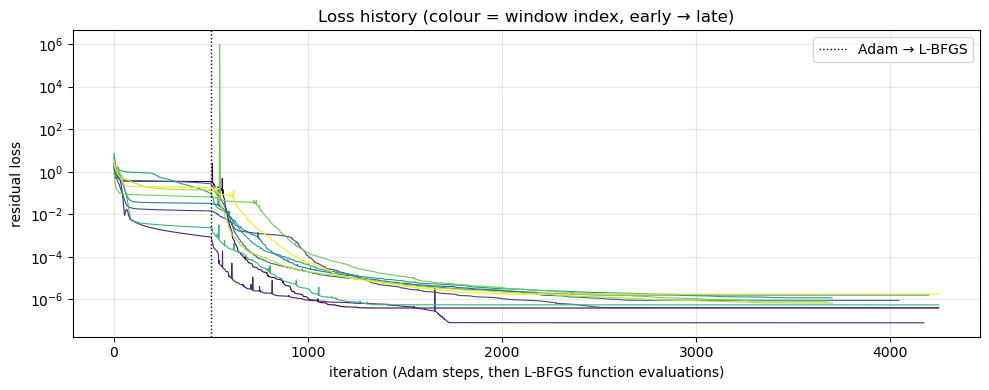

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
cmap = plt.get_cmap("viridis")
for k, history in enumerate(histories):
    ax.semilogy(history, color=cmap(k / max(len(histories) - 1, 1)), lw=0.8)
ax.axvline(adam_epochs, color="k", ls=":", lw=1, label="Adam → L-BFGS")
ax.set_xlabel("iteration (Adam steps, then L-BFGS function evaluations)")
ax.set_ylabel("residual loss")
ax.set_title("Loss history (colour = window index, early → late)")
ax.legend()
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()